# Objetivo do trabalho
Uso do ResNet34 para detecção de cancer de intestino
- Dateset: DykeF/NCTCRCHE100K
- 100K imagens de treinamento e 7180 para teste
- resolução transformadas: 224 x 224 pixeis

In [2]:
import tqdm
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import kagglehub
import shutil
from typing import Tuple
from PIL import Image
from imblearn.combine import SMOTETomek
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import albumentations as A
import cv2
from albumentations.pytorch import ToTensorV2
import os
import datetime
import torchvision
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tabulate import tabulate
import seaborn as sns
import copy

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"Using: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")
else:
    print("CUDA is not available. Using CPU.")

Using: NVIDIA A100-SXM4-40GB
CUDA: 12.6


In [5]:
!pip install -q datasets==2.14.6

In [7]:
from datasets import load_dataset
ds = load_dataset("DykeF/NCTCRCHE100K")

Generating train split: 0 examples [00:00, ? examples/s]

Generating train_nonorm split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


In [ ]:
ds

In [8]:
splited = ds["train"].train_test_split(test_size=0.2, seed=42)
dataset_train = splited["train"]
dataset_validation = splited["test"]
dataset_test = ds["validation"]

In [9]:
set(dataset_train["label"])

{'ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM'}

In [10]:
cancer_classes = {"TUM"}
normal_classes = {"ADI", "BACK", "DEB", "LYM", "MUC", "MUS", "NORM", "STR"}

In [11]:

print(f"\nNumber of images in training dataset: {len(dataset_train)}")
print(f"Number of images in validation dataset: {len(dataset_validation)}")
print(f"Number of images in test dataset: {len(dataset_test)}")


Number of images in training dataset: 80000
Number of images in validation dataset: 20000
Number of images in test dataset: 7180


In [12]:
def to_binary(example):
    if example["label"] == "TUM":
        example["label"] = 1
    else:
        example["label"] = 0
    return example

dataset_train = dataset_train.map(to_binary)
dataset_validation = dataset_validation.map(to_binary)
dataset_test = dataset_test.map(to_binary)

print(f"\nNumber of images in training dataset: {len(dataset_train)}")
print(f"Number of images in validation dataset: {len(dataset_validation)}")
print(f"Number of images in test dataset: {len(dataset_test)}")


Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7180 [00:00<?, ? examples/s]


Number of images in training dataset: 80000
Number of images in validation dataset: 20000
Number of images in test dataset: 7180


In [13]:
set(dataset_train["label"])

{0, 1}

In [14]:
print(dataset_train.features)

{'image': Image(decode=True, id=None), 'label': Value(dtype='int64', id=None), 'file': Value(dtype='string', id=None)}


In [15]:
class NCTCRCHE100KDatasetMemory(Dataset):
    def __init__(self, hf_dataset, transforms=None):
        self.transforms = transforms

        self.images = []
        self.labels = []

        for item in hf_dataset:
            image = item["image"].convert("RGB")
            image = np.array(image)

            self.images.append(image)
            self.labels.append(item["label"])

        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transforms:
            image = self.transforms(image=image)["image"]

        return image, label
    
class CustomDatasetConfig:
    VAL_SIZE = 0.2
    SEED = 0x40

    TEST_TRANSFORMS = A.Compose([
        A.Resize(224, 224),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

    TRAIN_TRANSFORMS = A.Compose([
        A.Resize(224, 224),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])


def get_dataloaders(df_train, df_validation, df_test, batch_size=64, num_workers=2):

    dataset_train = NCTCRCHE100KDatasetMemory(df_train, transforms=CustomDatasetConfig.TRAIN_TRANSFORMS)
    dataset_validation = NCTCRCHE100KDatasetMemory(df_validation, transforms=CustomDatasetConfig.TEST_TRANSFORMS)
    dataset_test = NCTCRCHE100KDatasetMemory(df_test, transforms=CustomDatasetConfig.TEST_TRANSFORMS)

    train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=num_workers)
    val_loader = DataLoader(dataset_validation, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=num_workers)
    test_loader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=num_workers)

    return train_loader, val_loader, test_loader

In [16]:
batch_size = 64
dataloader_train, dataloader_validation, dataloader_test = get_dataloaders(dataset_train, dataset_validation, dataset_test, batch_size, 2)

### hiperparametros
- numero de canais de entrada: 3
- numero de classes de saída: 2
- taxa de aprendizado: 1e-4
- otimizador: Adam
- número de épocas: 50

In [17]:
in_channels = 3
output_features = 2
learning_rate = 1e-4

In [18]:
model = torchvision.models.resnet34(num_classes=output_features)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


### Treinamento

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
criterion = torch.nn.CrossEntropyLoss()

def train_model(model, dataloader_train, dataloader_validation, optimizer, epochs = 10, patience = 0, scheduler = None, drive_path = '/content/drive/MyDrive/Machine Learning/Resultados TCC/models/NCTCRCHE100K/Adam/normal/ResNet34_best.pt'):
    model = model.to("cuda")
    device = "cuda"
    train_losses = []
    val_losses = []
    best_loss = float("inf")
    best_model_state = None
    epochs_no_improve = 0
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_loss_validation = 0

        for images, labels in dataloader_train:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size()[0]

        with torch.no_grad():
            model.eval() 

            for images, labels in dataloader_validation:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss_validation += loss.item() * images.size()[0]
            

        avg_train_loss = total_loss / len(dataloader_train.dataset)
        avg_val_loss = total_loss_validation / len(dataloader_validation.dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        if scheduler is not None:
            scheduler.step()

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), f"{model.__class__.__name__}.pt")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        if patience > 0 and epochs_no_improve >= patience:
            print(f"\nEarly stopping ativado! Melhor Val Loss: {best_loss:.4f}")
            break
    
    model.load_state_dict(best_model_state)
    os.makedirs(drive_path, exist_ok=True)
    best_path = drive_path + f"/{model.__class__.__name__}_best.pt"
    torch.save(best_model_state, best_path)
    return train_losses, val_losses, model

def test_model(model, device, dataloader_test):
    model = model.to(device)
    model.eval()  # Modo de avaliação
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader_test:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Cálculo das métricas
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"Acurácia: {acc:.4f}")
    print(f"Precisão (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall:.4f}")
    print(f"F1-score (weighted): {f1:.4f}")
    print("Matriz de Confusão:")
    print(cm)

    return acc, precision, recall, f1, cm


In [21]:
train_losses, val_losses, best_model = train_model(model, dataloader_train, dataloader_validation, optimizer, 50, 15)

Epoch 1/50 | Train Loss: 0.0916 | Val Loss: 0.0647
Epoch 2/50 | Train Loss: 0.0484 | Val Loss: 0.0467
Epoch 3/50 | Train Loss: 0.0358 | Val Loss: 0.0531
Epoch 4/50 | Train Loss: 0.0286 | Val Loss: 0.0489
Epoch 5/50 | Train Loss: 0.0234 | Val Loss: 0.0284
Epoch 6/50 | Train Loss: 0.0188 | Val Loss: 0.0288
Epoch 7/50 | Train Loss: 0.0148 | Val Loss: 0.0339
Epoch 8/50 | Train Loss: 0.0120 | Val Loss: 0.0318
Epoch 9/50 | Train Loss: 0.0095 | Val Loss: 0.0408
Epoch 10/50 | Train Loss: 0.0089 | Val Loss: 0.0288
Epoch 11/50 | Train Loss: 0.0069 | Val Loss: 0.0259
Epoch 12/50 | Train Loss: 0.0059 | Val Loss: 0.0375
Epoch 13/50 | Train Loss: 0.0074 | Val Loss: 0.0482
Epoch 14/50 | Train Loss: 0.0054 | Val Loss: 0.0331
Epoch 15/50 | Train Loss: 0.0059 | Val Loss: 0.0291
Epoch 16/50 | Train Loss: 0.0043 | Val Loss: 0.0373
Epoch 17/50 | Train Loss: 0.0044 | Val Loss: 0.0368
Epoch 18/50 | Train Loss: 0.0040 | Val Loss: 0.0747
Epoch 19/50 | Train Loss: 0.0048 | Val Loss: 0.0370
Epoch 20/50 | Train L

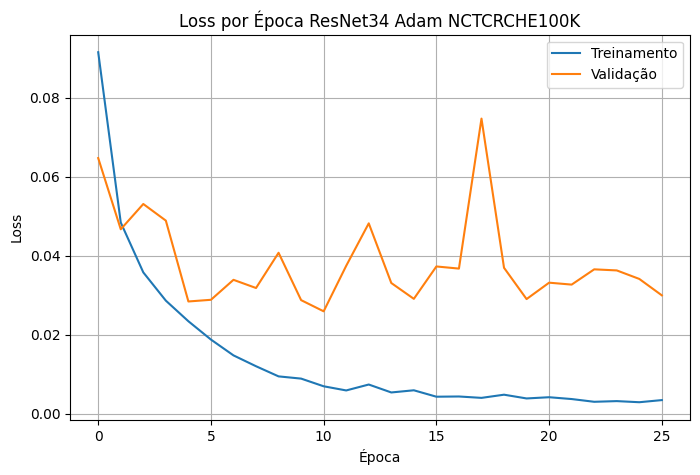

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época ResNet34 Adam NCTCRCHE100K")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
acc, precision, recall, f1, cm = test_model(model, "cuda", dataloader_test)

Acurácia: 0.9741
Precisão (weighted): 0.9746
Recall (weighted): 0.9741
F1-score (weighted): 0.9743
Matriz de Confusão:
[[5832  115]
 [  71 1162]]


In [24]:
headers = ["Métrica ResNet34 Adam NCTCRCHE100K", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒══════════════════════════════════════╤═════════╕
│ Métrica ResNet34 Adam NCTCRCHE100K   │   Valor │
╞══════════════════════════════════════╪═════════╡
│ Acurácia                             │  0.9741 │
├──────────────────────────────────────┼─────────┤
│ Precisão (weighted)                  │  0.9746 │
├──────────────────────────────────────┼─────────┤
│ Recall (weighted)                    │  0.9741 │
├──────────────────────────────────────┼─────────┤
│ F1-score (weighted)                  │  0.9743 │
╘══════════════════════════════════════╧═════════╛


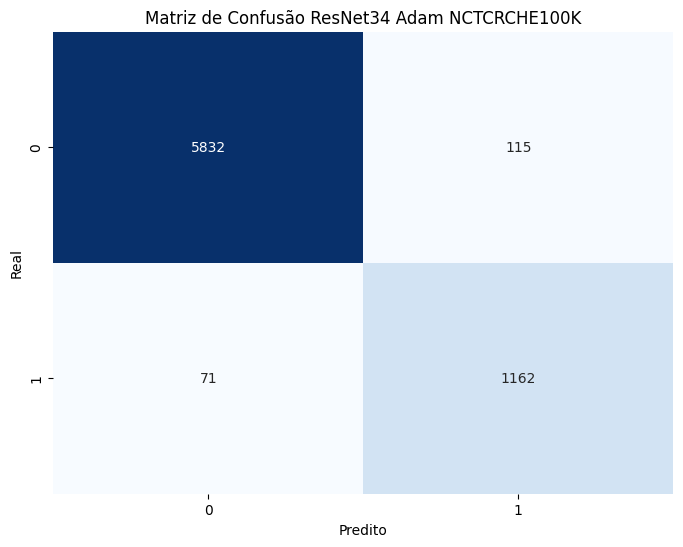

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão ResNet34 Adam NCTCRCHE100K")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

## Rodando testes com diferentes DataSets
- LC25000
- CRC5000

In [26]:
batch_size = 64
output_features = 2

In [27]:
path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")
shutil.copytree(path, "/content/", dirs_exist_ok=True)
!ls lung_colon_image_set

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
colon_image_sets  lung_image_sets


In [28]:
class LC25000Formatter:
    def __init__(self, input_path, output_csv):
        self.input_path = input_path
        self.output_csv_path = output_csv

    def run(self):
        df = self.process_directory(self.input_path)
        df.to_csv(self.output_csv_path, index=False)
        print(f"CSV salvo com sucesso em: {self.output_csv_path}")

    def process_directory(self, input_path: str):
        label_map = {
            "colon_n": int(0),
            "colon_aca": int(1)
        }
        image_extensions = ['.jpg', '.jpeg', '.png']
        image_paths = list(self.input_path.glob('**/*'))

        data = []
        for path in tqdm.tqdm(image_paths):
            if path.suffix.lower() in image_extensions and path.is_file():
                label = path.parent.name
                segmentation = path.parent.name
                data.append({
                    "path": str(path.resolve()),
                    "label": label_map[label],
                    "segmentation": segmentation
                })

        df = pd.DataFrame(data)
        return df

In [29]:
 
path_to_dataset_lc = pathlib.Path('/content/lung_colon_image_set/colon_image_sets')
LC25000Formatter(input_path = path_to_dataset_lc, output_csv = "nb_lc25000.csv").run()
dataframe_lc = pd.read_csv("/content/nb_lc25000.csv")
df_test_lc = dataframe_lc[["path", "label"]]
print(f"Number of images in test dataset lc25000: {len(df_test_lc)}")

100%|██████████| 10002/10002 [00:00<00:00, 25780.19it/s]


CSV salvo com sucesso em: nb_lc25000.csv
Number of images in test dataset lc25000: 10000


In [30]:
class LC25000DatasetMemory(Dataset):
    def __init__(self, dataframe, transforms=None, target_column="label"):
        self.dataframe = dataframe
        self.transforms = transforms
        self.target_column = target_column

        self.images = []
        self.labels = []

        for idx, row in dataframe.iterrows():
            image_path = row["path"]
            image = Image.open(image_path).convert("RGB")
            image_np = np.array(image)

            if self.transforms:
                transformed = self.transforms(image=image_np)
                image_tensor = transformed["image"]
            else:
                image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)  # fallback

            self.images.append(image_tensor)
            self.labels.append(row[target_column])

        self.images = torch.stack(self.images)
        self.labels = torch.tensor(self.labels)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]
    

class CustomDatasetConfig:
    VAL_SIZE = 0.2
    SEED = 0x40

    TEST_TRANSFORMS = A.Compose([
        A.Resize(224, 224),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

    TRAIN_TRANSFORMS = A.Compose([
        A.Resize(224, 224),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

In [31]:
dataset_test_lc = LC25000DatasetMemory(
        df_test_lc,
        transforms=CustomDatasetConfig.TEST_TRANSFORMS,
        target_column="label",
    )
dataloader_test_lc = DataLoader(dataset_test_lc, batch_size= batch_size, pin_memory = True,shuffle= False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

**Atenção: apenas rode o trecho de código abaixo caso não esteja rodando o notebook todo de uma vez**

In [ ]:
model = torchvision.models.resnet34(num_classes=output_features)
path = "/content/drive/MyDrive/Machine Learning/Resultados TCC/models/NCTCRCHE100K/Adam/normal/ResNet34_best.pt"
model.load_state_dict(torch.load(path, map_location="cuda"))

In [32]:
acc, precision, recall, f1, cm = test_model(model, "cuda", dataloader_test_lc)

Acurácia: 0.5144
Precisão (weighted): 0.7537
Recall (weighted): 0.5144
F1-score (weighted): 0.3646
Matriz de Confusão:
[[5000    0]
 [4856  144]]


In [33]:
headers = ["Métrica ResNet34 Adam LC25000", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════════════════╤═════════╕
│ Métrica ResNet34 Adam LC25000   │   Valor │
╞═════════════════════════════════╪═════════╡
│ Acurácia                        │  0.5144 │
├─────────────────────────────────┼─────────┤
│ Precisão (weighted)             │  0.7537 │
├─────────────────────────────────┼─────────┤
│ Recall (weighted)               │  0.5144 │
├─────────────────────────────────┼─────────┤
│ F1-score (weighted)             │  0.3646 │
╘═════════════════════════════════╧═════════╛


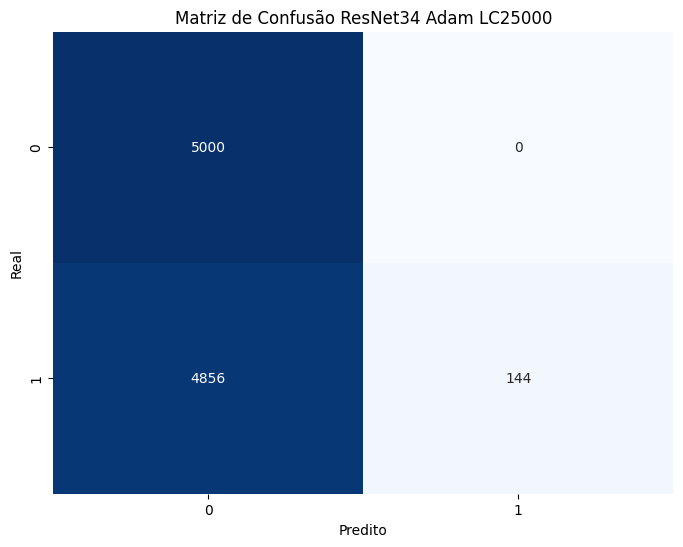

In [34]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão ResNet34 Adam LC25000")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [35]:

path = kagglehub.dataset_download("kmader/colorectal-histology-mnist")
shutil.copytree(path, "/content/", dirs_exist_ok=True)
!ls Kather_texture_2016_image_tiles_5000/Kather_texture_2016_image_tiles_5000


100%|██████████| 1.90G/1.90G [01:29<00:00, 22.9MB/s]

Extracting files...


01_TUMOR   03_COMPLEX  05_DEBRIS  07_ADIPOSE
02_STROMA  04_LYMPHO   06_MUCOSA  08_EMPTY


In [36]:
class CRC5000Formatter:
    def __init__(self, input_path, output_csv):
        self.input_path = input_path
        self.output_csv_path = output_csv

    def run(self):
        df = self.process_directory(self.input_path)
        df.to_csv(self.output_csv_path, index=False)
        print(f"CSV salvo com sucesso em: {self.output_csv_path}")

    def process_directory(self, input_path: str):
        label_map = {
            "01_TUMOR": int(1),
            "02_STROMA": int(0),
            "03_COMPLEX": int(0),
            "04_LYMPHO": int(0),
            "05_DEBRIS": int(0),
            "06_MUCOSA": int(0),
            "07_ADIPOSE": int(0),
            "08_EMPTY": int(0),
        }
        image_extensions = ['.tif', '.tiff']
        image_paths = list(self.input_path.glob('**/*'))

        data = []
        for path in tqdm.tqdm(image_paths):
            if path.suffix.lower() in image_extensions and path.is_file():
                label = path.parent.name
                if label not in label_map:
                    continue
                segmentation = path.parent.name
                data.append({
                    "path": str(path.resolve()),
                    "label": label_map[label],
                    "segmentation": segmentation
                })

        df = pd.DataFrame(data)
        return df
    

In [37]:
path_to_dataset_crc = pathlib.Path('/content/Kather_texture_2016_image_tiles_5000/Kather_texture_2016_image_tiles_5000')
CRC5000Formatter(input_path = path_to_dataset_crc, output_csv = "nb_crc5000.csv").run()
dataframe_crc = pd.read_csv("/content/nb_crc5000.csv")
df_test_crc = dataframe_crc[["path", "label"]]
print(f"Number of images in test dataset crc5000: {len(df_test_crc)}")

100%|██████████| 5008/5008 [00:00<00:00, 23591.72it/s]

CSV salvo com sucesso em: nb_crc5000.csv
Number of images in test dataset crc5000: 5000


In [38]:
class CRC5000DatasetMemory(Dataset):
    def __init__(self, dataframe, transforms=None, target_column="label"):
        self.dataframe = dataframe
        self.transforms = transforms
        self.target_column = target_column

        self.images = []
        self.labels = []

        for idx, row in dataframe.iterrows():
            image_path = row["path"]
            image = Image.open(image_path).convert("RGB")
            image_np = np.array(image)

            if self.transforms:
                transformed = self.transforms(image=image_np)
                image_tensor = transformed["image"]
            else:
                image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)  # fallback

            self.images.append(image_tensor)
            self.labels.append(row[target_column])

        self.images = torch.stack(self.images)
        self.labels = torch.tensor(self.labels)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


In [39]:
dataset_test_crc = CRC5000DatasetMemory(
        df_test_crc,
        transforms=CustomDatasetConfig.TEST_TRANSFORMS,
        target_column="label",
    )
dataloader_test_crc = DataLoader(dataset_test_crc, batch_size= batch_size, pin_memory = True,shuffle= False)

In [40]:
acc, precision, recall, f1, cm = test_model(model, "cuda", dataloader_test_crc)

Acurácia: 0.8138
Precisão (weighted): 0.7585
Recall (weighted): 0.8138
F1-score (weighted): 0.7852
Matriz de Confusão:
[[4069  306]
 [ 625    0]]


In [41]:
headers = ["Métrica ResNet34 Adam CRC5000", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════════════════╤═════════╕
│ Métrica ResNet34 Adam CRC5000   │   Valor │
╞═════════════════════════════════╪═════════╡
│ Acurácia                        │  0.8138 │
├─────────────────────────────────┼─────────┤
│ Precisão (weighted)             │  0.7585 │
├─────────────────────────────────┼─────────┤
│ Recall (weighted)               │  0.8138 │
├─────────────────────────────────┼─────────┤
│ F1-score (weighted)             │  0.7852 │
╘═════════════════════════════════╧═════════╛


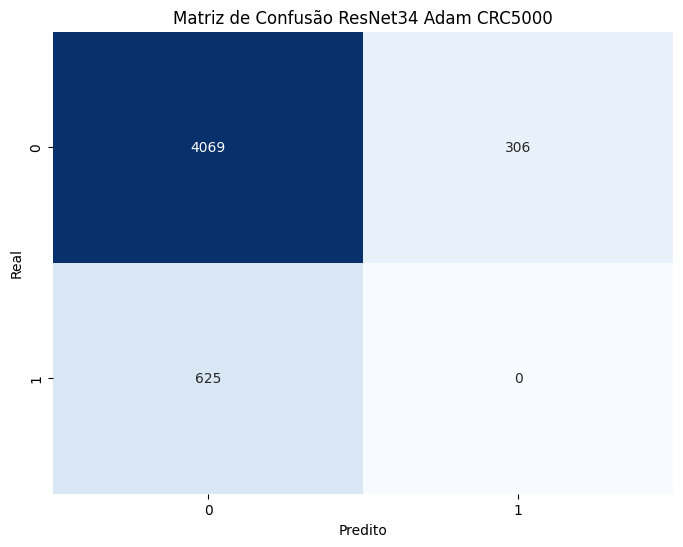

In [42]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão ResNet34 Adam CRC5000")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()